# 01 — Data and Baselines

Build the feature set and establish the benchmarks that any regime model must beat.

**Why baselines first?** Observable rules require no estimation, carry no model risk, and
are trivially reproducible. If a latent-variable model cannot beat a one-line rule on
realised volatility, the model adds nothing. Establishing this bar *before* fitting
anything prevents motivated reasoning later.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys; sys.path.append('..')

from regime_utils import load_data, backtest, metrics, metrics_header, COST

## Features

- `returns` — daily log return ×100
- `volatility` — 21-day rolling std, annualised (×√252)
- `momentum` — 21-day cumulative log return ×100

All features are computed first and dropped *once* at the end, guaranteeing the columns
share an identical index.

In [2]:
df, data = load_data("SPY", start="2006-01-01", end="2025-01-01")
print(df.shape)
df.describe()

[*********************100%***********************]  1 of 1 completed

(4760, 3)


,returns,volatility,momentum
count,4760.000000,4760.000000,4760.000000
mean,0.039439,15.970977,0.839279
std,1.224376,11.278045,4.830101
min,-11.588640,3.415720,-39.677198
25%,-0.398434,9.308817,-1.052520
50%,0.066909,13.221076,1.591277
75%,0.589618,18.940343,3.533754
max,13.557757,93.668321,22.462253


### Reading the data

Two things worth noting before modelling:

1. **Returns are not Gaussian.** The minimum daily return is ≈ −11.6% against a standard
   deviation of ≈ 1.2 — roughly a 10-sigma event, which under a normal distribution has
   probability ~1e-23. The tails are far heavier than any Gaussian model assumes. This is
   the motivation for testing a non-parametric alternative (notebook 03).

2. **Volatility is right-skewed.** Mean ≈ 16%, median ≈ 13%, max ≈ 94% (COVID). The market
   sits calm most of the time with explosive episodes. That asymmetry is the regime
   structure a model should recover.

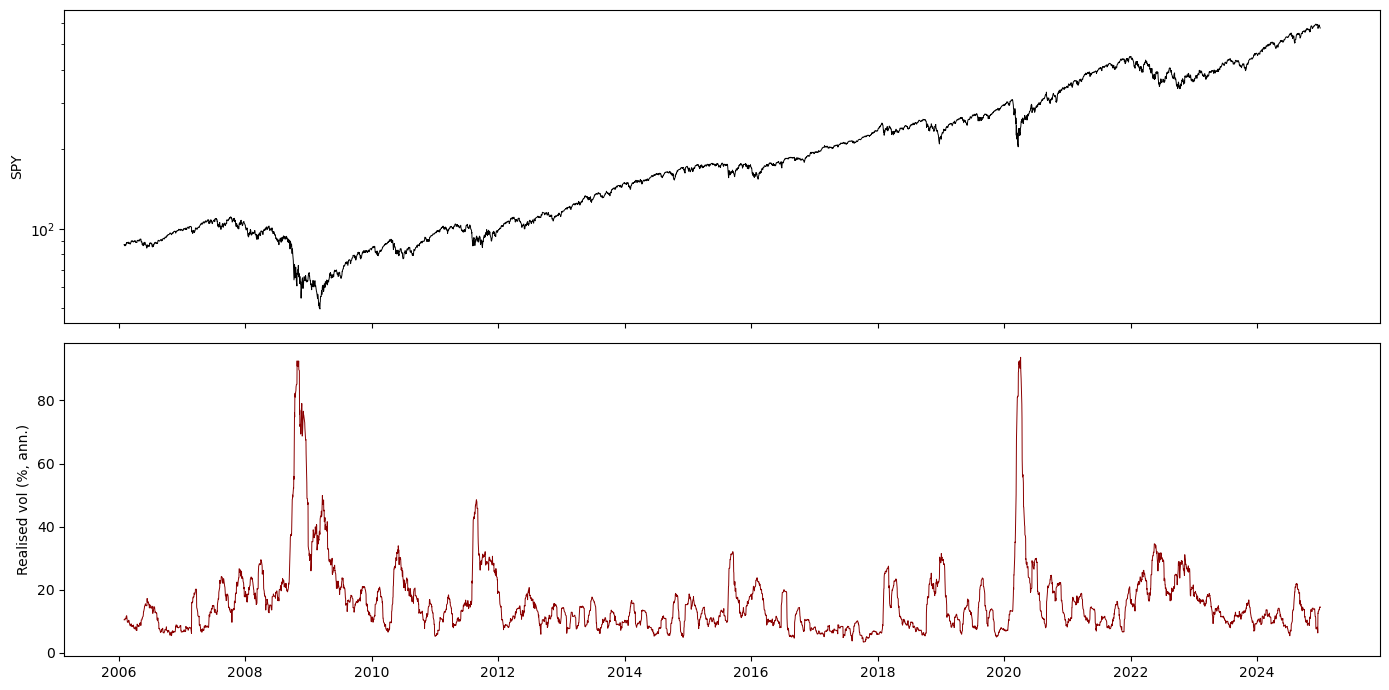

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(data["Close"].loc[df.index], color="black", linewidth=0.7)
axes[0].set_ylabel("SPY"); axes[0].set_yscale("log")
axes[1].plot(df.index, df["volatility"], color="darkred", linewidth=0.7)
axes[1].set_ylabel("Realised vol (%, ann.)")
plt.tight_layout(); plt.show()

## Baselines

**Buy & hold** — the honest floor. Any strategy that fails to beat it on a risk-adjusted
basis is not worth its complexity.

**Realised-volatility targeting** — reduce exposure when volatility exceeds its own
historical median. 

We use the **expanding** median, not full-sample, to prevent the look-ahead bias we all know produces unrealistic returns.

In [5]:
bt = pd.DataFrame(index=df.index)
bt["ret"] = df["returns"] / 100
bt["expo_bh"] = 1.0

vol = df["volatility"]
expanding_median = vol.expanding(min_periods=250).median()   # causal threshold
bt["expo_vol"] = np.where(vol < expanding_median, 1.0, 0.5)
bt.to_pickle("data/baselines.pkl")

'''
Since the HMM needs 4 years of training, the strategies are evaluated over the same period of time in notebook 04

bt["ret_bh"]  = backtest(bt["expo_bh"],  bt["ret"])
bt["ret_vol"] = backtest(bt["expo_vol"], bt["ret"])

metrics_header()
metrics(bt["ret_bh"],  "Buy & Hold")
metrics(bt["ret_vol"], "Vol target (baseline)")
'''

'\nSince the HMM needs 4 years of training, the strategies are evaluated over the same period of time in notebook 04\n\nbt["ret_bh"]  = backtest(bt["expo_bh"],  bt["ret"])\nbt["ret_vol"] = backtest(bt["expo_vol"], bt["ret"])\n\nmetrics_header()\nmetrics(bt["ret_bh"],  "Buy & Hold")\nmetrics(bt["ret_vol"], "Vol target (baseline)")\n'

In [6]:
# métricas indicativas sobre el periodo del backtest final (post-2010)
bt_align = bt.loc["2010-03-02":]
metrics_header()
metrics(backtest(bt_align["expo_bh"],  bt_align["ret"]), "Buy & Hold")
metrics(backtest(bt_align["expo_vol"], bt_align["ret"]), "Vol target")

Strategy               |    CAGR |     Vol | Sharpe |    MaxDD
--------------------------------------------------------------------
Buy & Hold             |  12.24% |  17.11% |   0.72 |  -35.75%
Vol target             |   9.54% |  11.52% |   0.83 |  -19.21%


{'cagr': np.float64(0.09540887565257572),
 'vol': np.float64(0.11524664415926504),
 'sharpe': np.float64(0.8278668446148026),
 'max_dd': np.float64(-0.19205053893019086)}